# PERSONAGE Multi-Model Benchmark — Phase 2 Analysis

Compares 7 base models using the Phase 1 winning config: `trait_first`, 11-shot, temp=0.3.

**Models:** Llama 3.3 70B, GPT-5.1, Gemini 3 Flash, Grok 4, Qwen 3.5 397B, Claude Sonnet 4.6, DeepSeek Chat

In [1]:
import json, glob
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12, "axes.labelsize": 10})

TRAITS = ["O", "C", "E", "A", "N"]
TRAIT_NAMES = {"O": "Openness", "C": "Conscientiousness", "E": "Extraversion", "A": "Agreeableness", "N": "Neuroticism"}
RESULTS_DIR = Path("../results")
BASELINE_R = 0.457

In [2]:
def load_benchmark_results(pattern="benchmark_*.jsonl"):
    all_rows = []
    for fp in sorted(RESULTS_DIR.glob(pattern)):
        with open(fp) as f:
            for line in f:
                line = line.strip()
                if line:
                    all_rows.append(json.loads(line))
    return pd.DataFrame(all_rows)

df = load_benchmark_results()
print(f"Total rows: {len(df)}")
if "model_key" in df.columns:
    print(f"Models: {df['model_key'].nunique()}")
    print(df['model_key'].value_counts())

Total rows: 560
Models: 7
model_key
claude-sonnet-4.6    80
deepseek-chat        80
gemini-3-flash       80
gpt-5.1              80
grok-4               80
llama-3.3-70b        80
qwen3.5-397b         80
Name: count, dtype: int64


In [3]:
def compute_metrics(group):
    results = {}
    valid = group.dropna(subset=["detected_ocean"])
    valid = valid[valid["detected_ocean"].apply(lambda x: isinstance(x, dict) and len(x) >= 1)]
    results["coverage"] = len(valid) / len(group) if len(group) > 0 else 0
    results["n_valid"] = len(valid)
    rs, maes = [], []
    for t in TRAITS:
        has_trait = valid["ground_truth_ocean"].apply(lambda x: t in x)
        sub = valid[has_trait]
        results[f"n_{t}"] = len(sub)
        if len(sub) < 5:
            results[f"r_{t}"] = np.nan
            results[f"mae_{t}"] = np.nan
            continue
        pred = sub["detected_ocean"].apply(lambda x: x.get(t, 0)).astype(float).values
        gt = sub["ground_truth_ocean"].apply(lambda x: x[t]).astype(float).values
        if np.std(pred) < 1e-8:
            r, mae = 0.0, float(np.mean(np.abs(pred - gt)))
        else:
            r, _ = stats.pearsonr(pred, gt)
            mae = float(np.mean(np.abs(pred - gt)))
        results[f"r_{t}"] = r
        results[f"mae_{t}"] = mae
        rs.append(r)
        maes.append(mae)
    results["macro_r"] = np.mean(rs) if rs else np.nan
    results["macro_mae"] = np.mean(maes) if maes else np.nan
    return pd.Series(results)

if len(df) > 0:
    summary = df.groupby("model_key").apply(compute_metrics).reset_index()
    summary = summary.sort_values("macro_r", ascending=False)
    display(summary[["model_key", "n_valid", "coverage", "macro_r", "macro_mae"] + [f"r_{t}" for t in TRAITS]])

,model_key,n_valid,coverage,macro_r,macro_mae,r_O,r_C,r_E,r_A,r_N
5,llama-3.3-70b,80.0,1.0000,0.660083,0.294998,0.516957,0.673074,0.478990,0.812407,0.818990
3,gpt-5.1,80.0,1.0000,0.651121,0.256876,0.572442,0.653122,0.418489,0.814627,0.796923
2,gemini-3-flash,63.0,0.7875,0.623338,0.269572,0.578853,0.616698,0.355560,0.799436,0.766142
4,grok-4,80.0,1.0000,0.619967,0.260831,0.599390,0.619351,0.337522,0.789320,0.754250
6,qwen3.5-397b,80.0,1.0000,0.585476,0.322011,0.459334,0.555629,0.411161,0.790770,0.710488
0,claude-sonnet-4.6,74.0,0.9250,0.571934,0.266728,0.390218,0.359650,0.476484,0.840306,0.793012
1,deepseek-chat,78.0,0.9750,0.568900,0.266153,0.494119,0.495237,0.387219,0.766073,0.701852


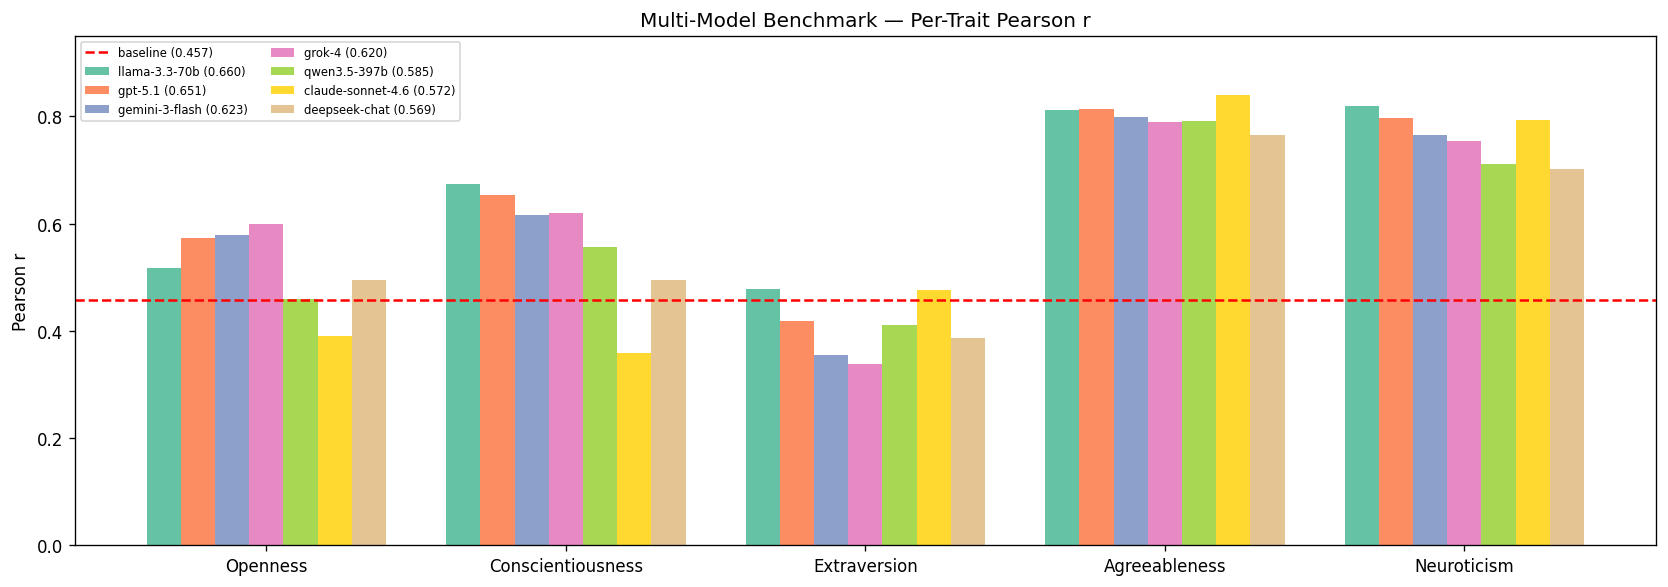

In [4]:
# Grouped bar chart: per-trait r by model
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(TRAITS))
n_models = len(summary)
width = 0.8 / max(n_models, 1)
colors = plt.cm.Set2(np.linspace(0, 1, n_models + 1))

for idx, (_, row) in enumerate(summary.iterrows()):
    rs = [row[f"r_{t}"] for t in TRAITS]
    ax.bar(x + idx * width, rs, width, label=f"{row['model_key']} ({row['macro_r']:.3f})", color=colors[idx])

ax.axhline(BASELINE_R, color="red", ls="--", lw=1.5, label=f"baseline ({BASELINE_R})")
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels([TRAIT_NAMES[t] for t in TRAITS], fontsize=10)
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 0.95)
ax.set_title("Multi-Model Benchmark — Per-Trait Pearson r")
ax.legend(fontsize=7, loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

In [5]:
# Model ensemble: average detected_ocean across all models per sample
valid = df.dropna(subset=["detected_ocean"])
valid = valid[valid["detected_ocean"].apply(lambda x: isinstance(x, dict) and len(x) >= 1)].copy()
for t in TRAITS:
    valid[f"pred_{t}"] = valid["detected_ocean"].apply(lambda x: x.get(t, 0))

ensemble_rs = []
print("Model Ensemble (averaged predictions across all 7 models):")
print(f"{'Trait':<20s} {'r':>8} {'MAE':>8}")
print("-" * 40)
for t in TRAITS:
    has_t = valid["ground_truth_ocean"].apply(lambda x: t in x)
    sub = valid[has_t]
    sub_gt = sub["ground_truth_ocean"].apply(lambda x: x[t]).astype(float)
    ens = sub.groupby("sample_id").agg(
        pred=(f"pred_{t}", "mean"),
        gt=(f"pred_{t}", lambda _: 0),
    )
    ens_full = sub.groupby("sample_id").agg({f"pred_{t}": "mean"}).rename(columns={f"pred_{t}": "pred"})
    gt_map = sub.groupby("sample_id").apply(lambda g: g["ground_truth_ocean"].iloc[0][t])
    ens_full["gt"] = gt_map
    r, _ = stats.pearsonr(ens_full["pred"], ens_full["gt"])
    mae = np.mean(np.abs(ens_full["pred"] - ens_full["gt"]))
    ensemble_rs.append(r)
    print(f"  {TRAIT_NAMES[t]:<18s} {r:>8.3f} {mae:>8.3f}")

print("-" * 40)
print(f"  {'Macro r':<18s} {np.mean(ensemble_rs):>8.3f}")
print()
best_single = summary.iloc[0]["macro_r"]
print(f"Best single model:  {summary.iloc[0]['model_key']} (r={best_single:.3f})")
print(f"Ensemble (7 models): r={np.mean(ensemble_rs):.3f}")
print(f"Delta: {np.mean(ensemble_rs) - best_single:+.3f}")

Model Ensemble (averaged predictions across all 7 models):
Trait                       r      MAE
----------------------------------------
  Openness              0.600    0.245
  Conscientiousness     0.659    0.227
  Extraversion          0.451    0.304
  Agreeableness         0.839    0.187
  Neuroticism           0.823    0.238
----------------------------------------
  Macro r               0.674

Best single model:  llama-3.3-70b (r=0.660)
Ensemble (7 models): r=0.674
Delta: +0.014


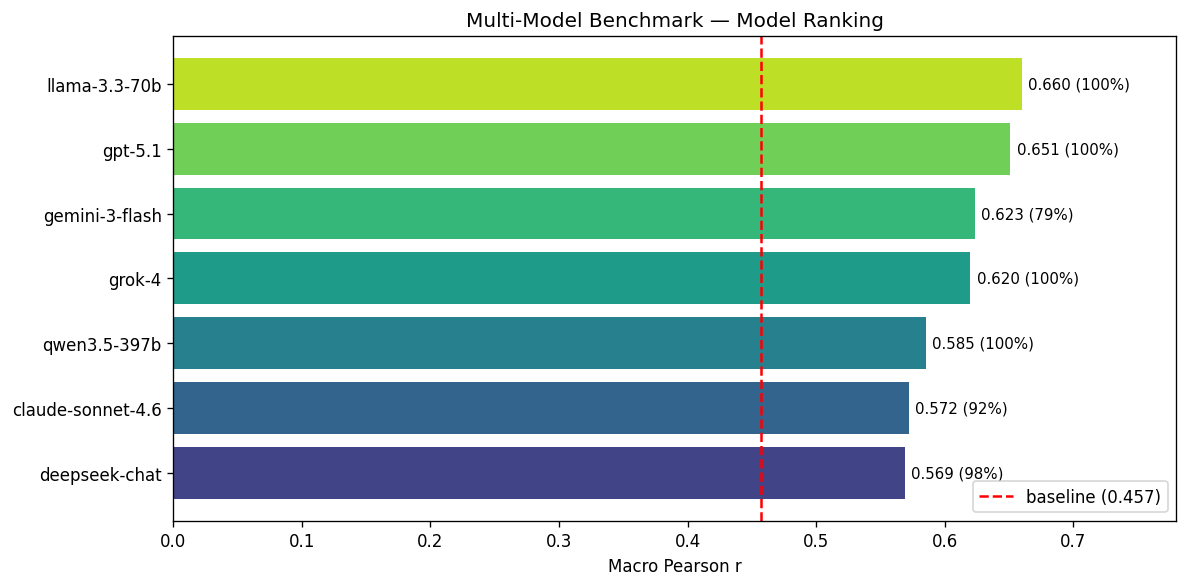

In [6]:
# Model ranking: horizontal bar chart
model_rank = summary.sort_values("macro_r", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(model_rank))
bars = ax.barh(y, model_rank["macro_r"], color=plt.cm.viridis(np.linspace(0.2, 0.9, len(model_rank))))
ax.set_yticks(y)
ax.set_yticklabels(model_rank["model_key"], fontsize=10)
ax.set_xlabel("Macro Pearson r")
ax.set_title("Multi-Model Benchmark — Model Ranking")
ax.axvline(BASELINE_R, color="red", ls="--", lw=1.5, label=f"baseline ({BASELINE_R})")

for bar, val, cov in zip(bars, model_rank["macro_r"], model_rank["coverage"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f} ({cov:.0%})", va="center", fontsize=9)

ax.legend()
ax.set_xlim(0, 0.78)
plt.tight_layout()
plt.show()

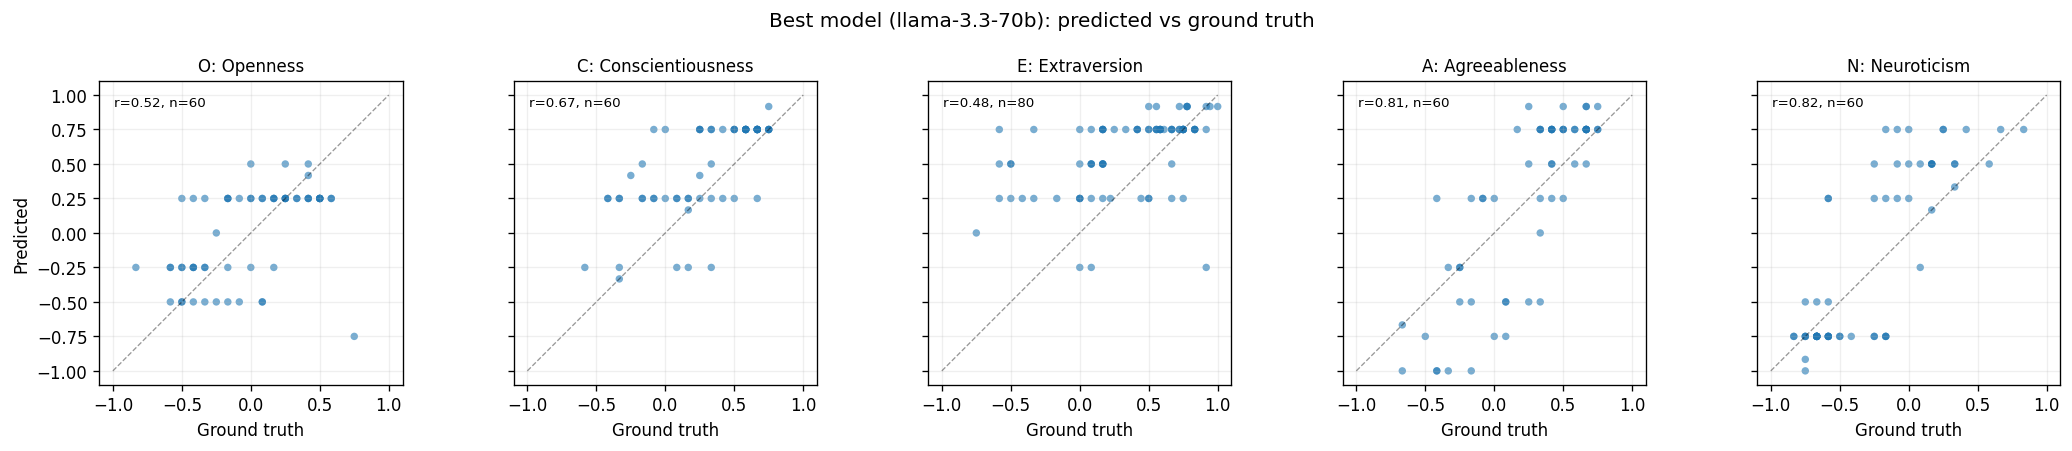

In [7]:
# Scatter: predicted vs ground truth for the best model (per trait)
best_model = summary.iloc[0]["model_key"]
best_data = df[df["model_key"] == best_model].copy()
best_valid = best_data.dropna(subset=["detected_ocean"])
best_valid = best_valid[best_valid["detected_ocean"].apply(lambda x: isinstance(x, dict) and len(x) >= 1)]

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)

for ax, t in zip(axes, TRAITS):
    has_t = best_valid["ground_truth_ocean"].apply(lambda x: t in x)
    sub = best_valid[has_t]
    pred = sub["detected_ocean"].apply(lambda x: x.get(t, 0)).astype(float).values
    gt = sub["ground_truth_ocean"].apply(lambda x: x[t]).astype(float).values

    ax.scatter(gt, pred, s=20, alpha=0.6, edgecolors="none")
    ax.plot([-1, 1], [-1, 1], "k--", lw=0.8, alpha=0.4)

    r = 0.0
    if len(pred) >= 5 and np.std(pred) > 1e-8:
        r, _ = stats.pearsonr(pred, gt)
    ax.text(0.05, 0.95, f"r={r:.2f}, n={len(pred)}", transform=ax.transAxes,
            fontsize=8, va="top")
    ax.set_title(f"{t}: {TRAIT_NAMES[t]}", fontsize=10)
    ax.set_xlabel("Ground truth")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Predicted")
fig.suptitle(f"Best model ({best_model}): predicted vs ground truth", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

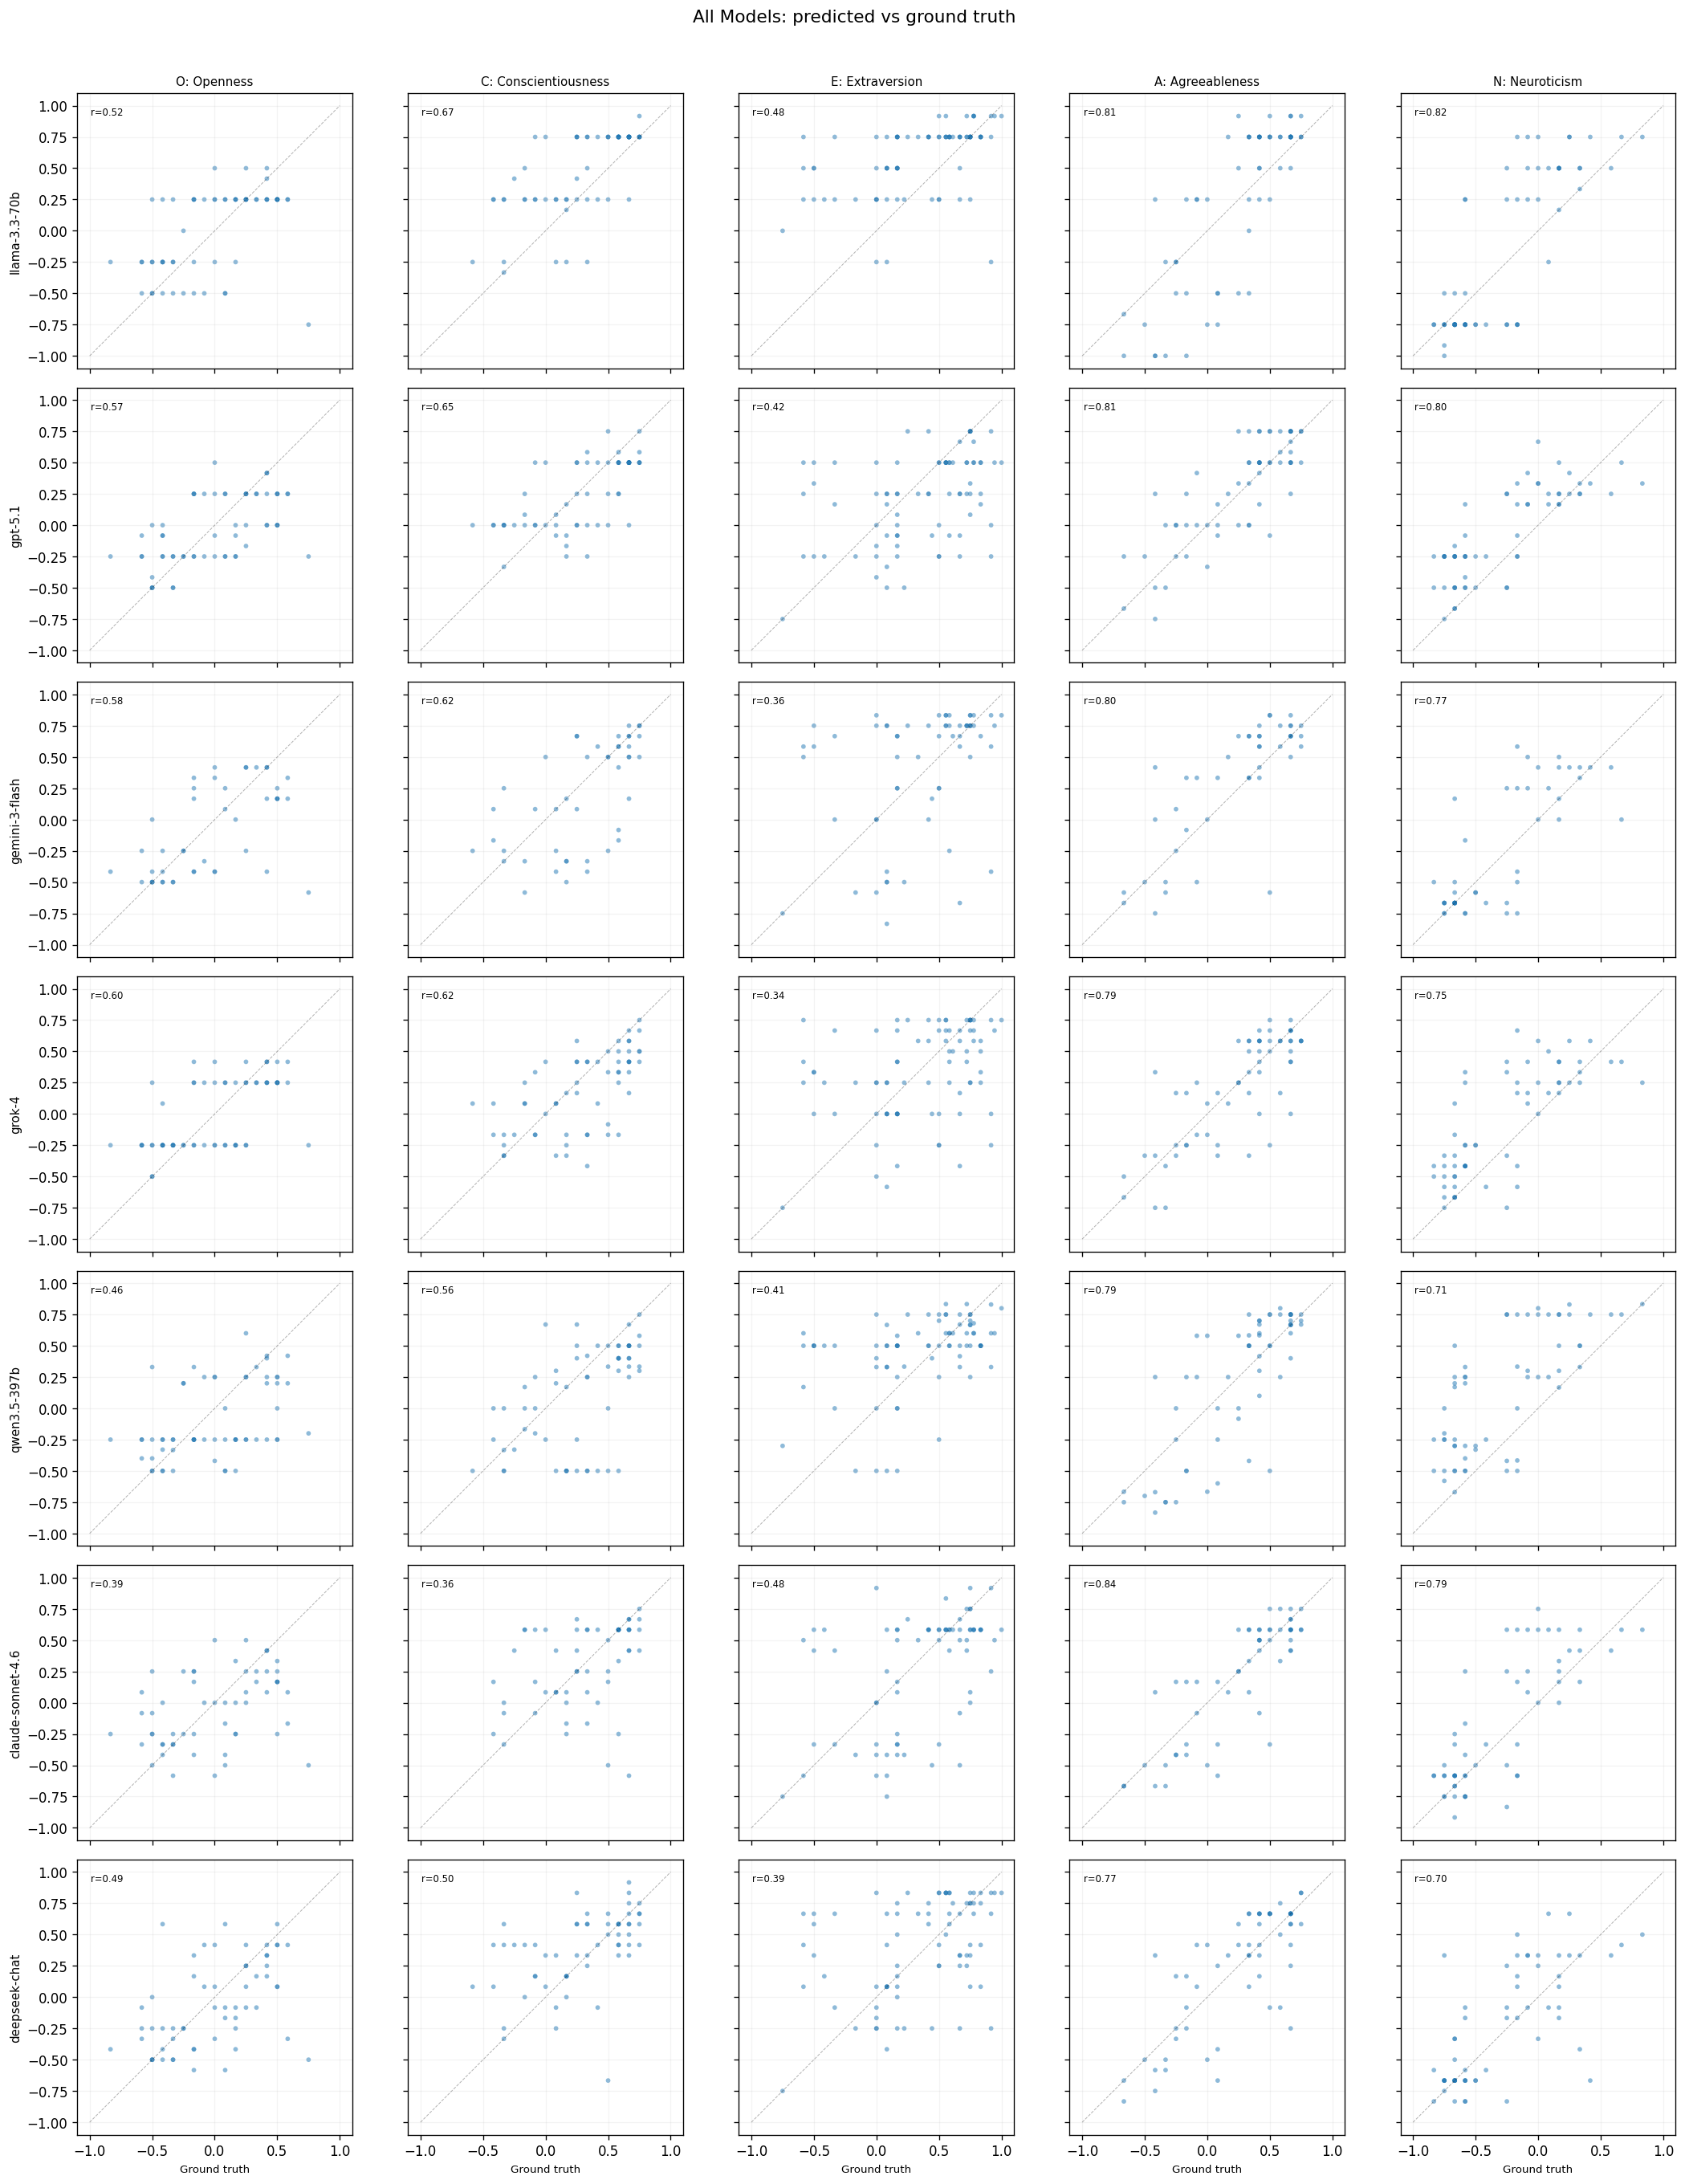

In [8]:
# Scatter: predicted vs ground truth for ALL models (one row per model)
models_sorted = summary["model_key"].tolist()

fig, axes = plt.subplots(len(models_sorted), 5, figsize=(18, 3.2 * len(models_sorted)), sharex=True, sharey=True)

for row_idx, model_key in enumerate(models_sorted):
    mdata = df[df["model_key"] == model_key].dropna(subset=["detected_ocean"])
    mdata = mdata[mdata["detected_ocean"].apply(lambda x: isinstance(x, dict) and len(x) >= 1)]

    for col_idx, t in enumerate(TRAITS):
        ax = axes[row_idx, col_idx]
        has_t = mdata["ground_truth_ocean"].apply(lambda x: t in x)
        sub = mdata[has_t]
        pred = sub["detected_ocean"].apply(lambda x: x.get(t, 0)).astype(float).values
        gt = sub["ground_truth_ocean"].apply(lambda x: x[t]).astype(float).values

        ax.scatter(gt, pred, s=12, alpha=0.5, edgecolors="none")
        ax.plot([-1, 1], [-1, 1], "k--", lw=0.6, alpha=0.3)

        r = 0.0
        if len(pred) >= 5 and np.std(pred) > 1e-8:
            r, _ = stats.pearsonr(pred, gt)
        ax.text(0.05, 0.95, f"r={r:.2f}", transform=ax.transAxes, fontsize=7, va="top")
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_aspect("equal")
        ax.grid(alpha=0.15)

        if row_idx == 0:
            ax.set_title(f"{t}: {TRAIT_NAMES[t]}", fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(model_key, fontsize=9)
        if row_idx == len(models_sorted) - 1:
            ax.set_xlabel("Ground truth", fontsize=8)

fig.suptitle("All Models: predicted vs ground truth", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Summary card
best = summary.iloc[0]
print("=" * 60)
print("  PHASE 2 BENCHMARK SUMMARY")
print("=" * 60)
print(f"  Models tested:    {len(summary)}")
print(f"  Prompt:           trait_first (11-shot, temp=0.3)")
print(f"  Samples per model: 80")
print()
print(f"  {'Model':<22s} {'Macro r':>8} {'Coverage':>10}")
print("-" * 45)
for _, row in summary.iterrows():
    print(f"  {row['model_key']:<22s} {row['macro_r']:>8.3f} {row['coverage']:>9.0%}")
print("-" * 45)
print()
print(f"  Best single model: {best['model_key']} (r={best['macro_r']:.3f})")
print(f"  Baseline:          r={BASELINE_R}")
delta = best["macro_r"] - BASELINE_R
print(f"  Improvement:       +{delta:.3f} ({delta/BASELINE_R*100:.0f}%)")
print("=" * 60)

  PHASE 2 BENCHMARK SUMMARY
  Models tested:    7
  Prompt:           trait_first (11-shot, temp=0.3)
  Samples per model: 80

  Model                   Macro r   Coverage
---------------------------------------------
  llama-3.3-70b             0.660      100%
  gpt-5.1                   0.651      100%
  gemini-3-flash            0.623       79%
  grok-4                    0.620      100%
  qwen3.5-397b              0.585      100%
  claude-sonnet-4.6         0.572       92%
  deepseek-chat             0.569       98%
---------------------------------------------

  Best single model: llama-3.3-70b (r=0.660)
  Baseline:          r=0.457
  Improvement:       +0.203 (44%)
